## 활성화 함수가 필요한 이유를 보여보자! (순전파)

## 헷갈렸던 부분 정리: 데이터, feature, 연결선, shape

### 1. 신경망 그림의 `x_1, x_2, ..., x_m`은 무엇인가?

일반적인 신경망 그림에서 `x_1, x_2, ..., x_m`은 **서로 다른 데이터 m개가 아니라, 데이터 하나가 가진 m개의 feature**를 뜻한다. 예를 들어 주택 데이터 하나라면 `x_1=면적`, `x_2=방 개수`, `x_3=연식`처럼 생각할 수 있다.

여러 데이터의 개수인 batch size `B`는 보통 그림에서 생략되어 있다.

```text
X의 행    = 데이터 개수 B
X의 열    = 입력 feature 개수 m
X.shape   = (B, m)
```

주의: 문맥에 따라 `x_1, x_2, x_3`가 실제로 각각 별개의 스칼라 데이터일 수도 있다. 그 경우 shape은 `(3, 1)`이다. 하지만 층을 그린 일반적인 신경망 도식에서는 대개 한 샘플의 feature들을 뜻한다.

### 2. 연결선 하나는 무엇인가?

입력 `x_j`에서 은닉 뉴런 `z_k`로 향하는 **선 하나**는 하나의 곱 `x_j w_{j,k}`를 뜻한다. 은닉 뉴런 `k`로 들어오는 모든 선의 값을 더하고, 그 뉴런의 bias `b_k`를 더하면 선형결합이 된다.

$$
u_k = b_k + \sum_{j=1}^{m} x_j w_{j,k}
$$

활성화 함수까지 적용하면 다음과 같다.

$$
z_k = f(u_k)
$$

교재에 따라 활성화 전 값을 `z_k`라고 부르기도 한다. 기호보다 중요한 것은 **선형변환 다음에 활성화 함수가 온다**는 계산 순서다.

```text
선 하나                 : x_j * w_(j,k)
뉴런으로 들어오는 선 전체: 가중합
뉴런마다 하나씩          : bias b_k
그다음                  : activation 적용
```

따라서 입력층과 은닉층 사이의 **선 전체가 가중치 행렬 `W`**라고 볼 수 있다.

### 3. 행렬로 한꺼번에 계산하기

데이터 한 개에 입력 feature가 `m`개, 은닉 뉴런이 `n`개라면:

```text
x:   (1, m)
W1:  (m, n)
b1:  (1, n)
U1:  (1, n)
Z1:  (1, n)

U1 = x @ W1 + b1
Z1 = activation(U1)
```

데이터가 `B`개라면 앞에 batch 차원만 붙는다.

```text
X:   (B, m)
W1:  (m, n)
b1:  (1, n)
U1:  (B, n)
Z1:  (B, n)

(B, m) @ (m, n) + (1, n) = (B, n)
```

출력 뉴런이 2개라면 두 번째 층은 다음과 같다.

```text
W2:     (n, 2)
b2:     (1, 2)
Y_hat:  (B, 2)

(B, n) @ (n, 2) + (1, 2) = (B, 2)
```

예를 들어 입력 feature 3개, 은닉 뉴런 4개, 출력 2개라면 `W1.shape=(3, 4)`, `W2.shape=(4, 2)`이다. 데이터 한 개의 최종 출력 shape은 `(1, 2)`이고, 데이터가 `B`개라면 `(B, 2)`이다.

### 4. `W`, `b`, `Z`의 차이

- `W`: 학습되는 가중치 행렬
- `b`: 학습되는 bias 벡터
- `U = XW + b`: 활성화 전 선형변환 결과
- `Z = f(U)`: 활성화 함수를 통과한 중간 결과

즉 `W`가 `z_1, ..., z_n`으로 구성되는 것이 아니다. `Z`는 입력과 파라미터 `W`, `b`를 계산해서 얻는 결과다.

### 5. Bias가 `(1, n)`이어도 되는 이유

Bias는 입력 feature마다 하나가 아니라 **출력 뉴런마다 하나**다. `b1.shape=(1, n)`이면 은닉 뉴런 `n`개 각각의 bias가 들어 있다. 모든 데이터가 동일한 뉴런과 파라미터를 공유하므로 NumPy가 같은 bias 벡터를 각 데이터 행에 broadcasting한다.

```text
[u11 u12 ... u1n]    [u11+b1 u12+b2 ... u1n+bn]
[u21 u22 ... u2n] -> [u21+b1 u22+b2 ... u2n+bn]
[u31 u32 ... u3n]    [u31+b1 u32+b2 ... u3n+bn]
```

`b`는 가중치가 아니다. `W`는 입력을 혼합하고 확대·축소하는 선형변환을 담당하고, `b`는 각 뉴런의 기준점을 이동시킨다.

### 한 문장 정리

> 신경망 그림의 입력 노드들은 보통 한 데이터의 feature들이고, 선 하나는 `입력 × 가중치` 하나를 나타낸다. 한 뉴런으로 모인 선들을 모두 합하고 그 뉴런의 bias를 더한 것이 `XW+b`이며, 여러 데이터는 그림에 생략된 batch 차원으로 처리된다.


(300, 2) (300,)
[[ 0.884408   -0.65607891]
 [ 0.07466918 -0.30576367]
 [ 0.86855581  0.63622971]]
[1 1 0 1 1 0 1 1 0 0]


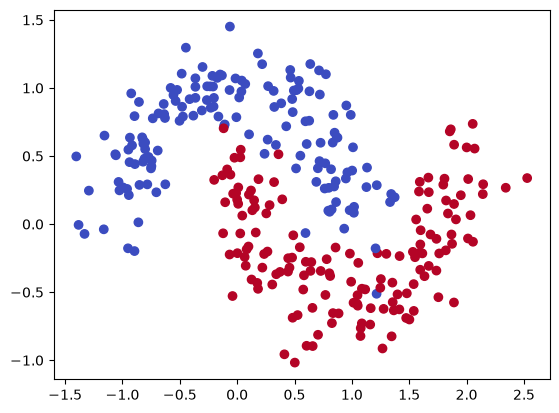

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=0)
print(X.shape, y.shape)        # (300, 2) (300,)
print(X[:3])                   # 점 3개의 좌표
print(y[:10])                  # 라벨 0/1

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.show()

위처럼, 이는 직선으로만 구분할 수 없다!
즉, 선형적인 분류로는 절대 이를 나눌 수 없음. 그렇기에 비선형적인 activate function이 필요하다

이에는 시그모이드, ReLU, Hyperbolic Tangent등이 필요하다.

이는 결국 선형 분리 불가능(non-linearly separable) 문제로 연결되고, 이것이 바로 은닉층이 필요한 이유이다.


### 순전파 코드를 넘파이로 짜서 확인해보자!

In [ ]:
import numpy as np

y = y.reshape(-1, 1) # row 개수는 알아서 계산해라

rng = np.random.default_rng(0) 
d, h = 2, 8 # 입력 2차원, 은닉층 뉴런 8개

W1 = rng.standard_normal((d, h)) * 0.1 # 표준 정규 분포에서 랜덤값 뽑기, 0.1 곱하는 이유는 시그모이드 함수에 맞추기 위해서
b1 = np.zeros((1, h)) # bias를 준다
W2 = rng.standard_normal((h, 1)) * 0.1 # 위와 같다.
b2 = np.zeros((1, 1)) # 은닉층 출력이 하나이므로, 이에 맞춘다

Z1 = X @ W1 + b1               # (300,2)@(2,8) → (300,8), broadcasting 이용!
A1 = np.maximum(0, Z1)         # ReLU
Z2 = A1 @ W2 + b2              # (300,8)@(8,1) → (300,1)
A2 = 1 / (1 + np.exp(-Z2))     # sigmoid

print(Z1.shape, A1.shape, Z2.shape, A2.shape)

eps = 1e-12 # log 0은 존재하지 않기 때문에
loss = -np.mean(y*np.log(A2+eps) + (1-y)*np.log(1-A2+eps)) # Binary Classification에서 가장 많이 사용된다.
print("loss =", loss)

# 파이토치로는 더 쉽게 구현할 수 있다!

(300, 8) (300, 8) (300, 1) (300, 1)
loss = 0.6933307351733705


## loss 코드 부분에 대한 더 자세한 정리

```python
loss = -np.mean(y*np.log(A2+eps) + (1-y)*np.log(1-A2+eps))
```

여기서 y는 정답(Label)을 의미한다.

이때 정답이 있으므로 이 과정은 지도학습에 해당된다.

예를 들어
```python
y =
[[1],
 [0],
 [1],
 [1],
 [0]]
 ```
이다.

A2는 모델이 예측한 확률에 해당된다.

### 왜 log를 사용할까?

손실 함수는 틀리면, 벌을 주고 맞으면 거의 벌주지 않는 함수이다.

즉 정답이 1인데, 모델이 99%라고 예측하면 Loss는 거의 0에 가깝다

반대로 1인데, 모델이 1%라고 예측하면 Loss는 매우 커진다.

그렇기에 식은 두 개로 나눠진다. 정답이 1인 경우 "-log(A2)" 정답이 0인 경우 "-log(1-A2)"

if 쓰기 귀찮으니까, 1-y, y로 한 것! -> 이거 클로드가 아니라함....

claude의 설명

첫째, "if 쓰기 귀찮으니까"는 직관은 맞는데 이유를 하나 더 넣으면 좋아. 

진짜 이유는 벡터화야. if문을 쓰면 데이터 300개를 하나씩 돌아야 하는데, y*...+(1-y)*...로 쓰면 300개가 행렬 연산 한 번에 처리돼. 

귀찮음의 문제가 아니라 속도의 문제고, GPU에서는 이 차이가 수십~수백 배로 벌어져. 

"분기를 곱셈으로 바꿔서 병렬화한다"가 딥러닝 코드 전반에 깔린 사고방식이야."


### eps는 왜 넣을까?

eps = 0.000000000001 이라는 매우 작은 숫자!

손실 함수 안에는 np.log(A2)가 있다.

만약 A2 = 0 이면 log(0)이 된다.

이는 발산하므로 이를 막기 위한 것이라고 보면 된다.

### PINN과 연결하자면?

지금 코드는 정답이 있고, Label과 비교하는 지도학습!

PINN에는 대부분 정답이 없고, PDE를 만족해야 한다는 조건을 갖는다.

그렇기에 PyTorch의 자동 미분을 이용해서 PDE의 왼쪽과 오른쪽이 같은지 비교한다.

즉, “정답(Label) 대신 물리 법칙(PDE)을 정답으로 사용하는 신경망”이라고 볼 수 있다


## PINN 부분 내가 정리한 것에 대한 Claude의 보충설명

### (1) PINN도 정답이 아예 없진 않아.

loss가 보통 두 덩어리야:

$$
L = L_{\mathrm{PDE}} + L_{\mathrm{BC/IC}}
$$

뒤쪽(경계조건·초기조건)은 사실 지금 네가 짠 거랑 똑같은 지도학습이야. "x=0에서 u는 반드시 0" 같은 알려진 값과 비교하는 거니까. 그래서 PINN은 "정답 없음"이 아니라 **"정답이 몇 군데만 있고, 나머지 빈 공간은 물리 법칙으로 채운다"**가 더 정확해. 이 구조 때문에 데이터가 적어도 학습이 되는 거고, 그게 PINN의 존재 이유야.

---

### (2) "왼쪽 오른쪽 비교"보다 residual 개념으로.

실제론 모든 항을 한쪽으로 몰아서 0이 돼야 하는 식을 만들어. 열방정식이면

$$
r = \frac{\partial u}{\partial t}
-
\alpha
\frac{\partial^2 u}{\partial x^2}
$$

그리고

$$
L_{\mathrm{PDE}}
=
\mathrm{mean}(r^2)
$$

즉 **"residual을 0으로 만드는 게 목표"**야. 그리고 여기서 loss가 BCE가 아니라 MSE인 것도 자연스러워 — 분류가 아니라 연속값을 맞추는 거니까.

---

### (3) 자동미분의 역할이 결정적으로 달라

이게 제일 중요해.

지금 네가 하는 역전파에서 미분은 파라미터(W, b)에 대한 미분이야. 학습하려고.

근데 PINN에서는 입력(x, t)에 대한 미분도 필요해.

$$
\frac{\partial u}{\partial t},
\qquad
\frac{\partial^2 u}{\partial x^2}
$$

가 바로 그거잖아.

즉 자동미분을 두 가지 목적으로 쓰는 거야.

- 입력에 대한 미분 → PDE 항을 만들려고 (loss를 구성하는 재료)
- 파라미터에 대한 미분 → 학습하려고 (기존과 동일)

이게 PINN이 가능한 진짜 이유야.

유한차분으로 격자를 깔지 않고도, 신경망이 매끄러운 함수니까 미분을 정확히 뽑아낼 수 있거든.



## 역전파 (Backpropagation)

### 역전파와 순전파의 순서
```text
[순전파]  X ──> [ W1 ] ──> Z1 ──> [ ReLU ] ──> A1 ──> [ W2 ] ──> Z2 ──> [ Sigmoid ] ──> A2 ──> Loss
                                                                                            │
[역전파] dX <─── dW1 <─── dZ1 <─────── dA1 <─── dW2 <─── dZ2 <──────────────────────────── (시작)
```

<br>

역전파는 오른쪽 끝(Loss)에서 출발해서 왼쪽으로 거슬러 오는 것

즉 오른쪽에서 **" 1. 출력이 바뀌면? Loss가 얼마나 바뀌는지"를 받고 -> 2. 그걸 내 파라미터에 대한 기울기와 내 입력에 대한 기울기로 바꾼다. "** 

### 1.

오른쪽(다음레이어)에서 $\frac{\partial L}{\partial y}$ 를 보내준다.

이게 바로 "출력이 바뀌면 loss가 얼마나 변화하는가?"를 의미함

예를 들어, $\frac{\partial L}{\partial y}$ = 3 이라면 출력 y를 1만큼 늘리면 loss가 대략 3 증가한다는 뜻이다.

즉 “출력을 어느 방향으로 바꾸면 loss가 줄어드는지”에 대한 정보를 받게 된다.

### 2.

"y에 대한 기울기"를 "W에 대한 기울기"로 변환해야 한다.

즉 

$\frac{\partial L}{\partial y}$

↓

$\frac{\partial L}{\partial W}$

이걸 계산해야 함 (파라미터 업데이트용 기울기)

왼쪽 레이어들도 학습해야 한다.

왼쪽 레이어들은 y를 모르고 x만 안다 (y = Wx + b) 이ㅣ기 때문이다.

실제 숫자로 본다면?

$$\begin{aligned} x &= 2 \\ W &= 5 \\ y &= Wx = 5 \times 2 = 10 \end{aligned}$$

loss를 계산한다면?

$\frac{\partial L}{\partial y}$ = 4

가 오른쪽에서 왔다.

**부연 설명**

모델의 출력이 y = 10 이고, 정답이 t = 8 이라 하자

L  = $(10-8)^2$ = 4

L = $(y-t)^2$ 이므로 미분하면... $\frac{\partial L}{\partial y}$  = $2(y-t)$

<br>

### 역전파의 규칙

규칙1. Linear layer ```Z = A @ W + b```일 때, dZ를 받으면:

```text
dw = A.T @ dz           db = dZ.sum(axis = 0, keepdims = True)          dA = dZ @ W.T
```

<br>

규칙2. 원소별 함수 ```A = f(Z)```일 때, ```dA```를 받으면:

```text
dZ = dA * f'(Z)         # 원소별 곱이다
```

<br>

규칙3. shape규칙: ```dw1.shape == W1.shape```이다. 늘 언제나..

<br>

### 부연 설명

0. 순전파(Forward Propagation)

하나의 Linear Layer는 다음과 같이 계산된다.

```text
입력 A
   │
   ▼
Z = A @ W + b
   │
   ▼
A = f(Z)
```

- `A` : 이전 Layer의 출력(현재 Layer의 입력)
- `W` : Weight(가중치)
- `b` : Bias
- `Z` : Linear Layer의 출력
- `f()` : ReLU, Sigmoid 등의 활성화 함수

---

1. 역전파의 목표

역전파에서는 오른쪽(Loss 쪽)에서

```text
dZ = ∂L/∂Z
```

또는

```text
dA = ∂L/∂A
```

를 받는다.

그리고 현재 Layer는 반드시 아래 두 가지를 계산해야 한다.

-  내 Weight를 얼마나 수정해야 하는가?

- 이전 Layer에게 무엇을 전달해야 하는가?

---

규칙 1. Linear Layer

Linear Layer

```text
Z = A @ W + b
```

에서 `dZ`를 받으면

```python
dW = A.T @ dZ

db = dZ.sum(axis=0, keepdims=True)

dA = dZ @ W.T
```

---

(1) dW

```python
dW = A.T @ dZ
```

의미

> Weight가 Loss에 얼마나 영향을 주는가

즉

```text
∂L/∂W
```

이다.

Weight 업데이트에 사용된다.

```python
W = W - lr * dW
```

---

왜 입력 A가 들어갈까?

예를 들어

```text
Z = AW
```

이면

Weight 하나를 조금 바꾸면

출력이 얼마나 변하는지는

입력 A에 비례한다.

즉

입력이 클수록

Weight의 영향도 커진다.

그래서

```text
dW = A.T @ dZ
```

가 된다.

---

(2) db

```python
db = dZ.sum(axis=0)
```

의미

Bias의 기울기

```text
∂L/∂b
```

이다.

Bias는

모든 데이터에 공통으로 더해진다.

```text
Z1 = ...
    + b

Z2 = ...
    + b

Z3 = ...
    + b
```

따라서

모든 데이터의 기울기를

더해야 한다.

그래서

```python
sum(axis=0)
```

을 사용한다.

---

(3) dA

```python
dA = dZ @ W.T
```

의미

현재 Layer의 입력에 대한 기울기

```text
∂L/∂A
```

이다.

이 값을

이전 Layer에게 전달한다.

즉

```text
Loss
 ↑
 │
현재 Layer
 ↑
 │
이전 Layer
```

에서

현재 Layer가

왼쪽으로 보내는 값이다.

---

규칙 2. Activation Layer

활성화 함수

```text
A = f(Z)
```

에서

오른쪽에서

```text
dA
```

를 받으면

```python
dZ = dA * f'(Z)
```

이다.

---

왜 곱할까?

체인룰 때문이다.

```text
L
│
▼
A = f(Z)
│
▼
Z
```

우리가 원하는 것은

```text
∂L/∂Z
```

이다.

체인룰을 적용하면

```text
∂L/∂Z

=

∂L/∂A

×

∂A/∂Z
```

즉

```python
dZ = dA * f'(Z)
```

이다.

---

ReLU 예시

```text
Z = [-3, 5]
```

ReLU의 미분은

```text
f'(Z)

=

[0, 1]
```

이다.

오른쪽에서

```text
dA

=

[4, 7]
```

가 왔다면

```python
dZ

=

[4,7]

*

[0,1]

=

[0,7]
```

즉

음수였던 뉴런은

기울기가 전달되지 않는다.

---

규칙 3. Shape 규칙

항상

```python
dW.shape == W.shape
```

이어야 한다.

예를 들어

```text
W

(3 × 5)
```

라면

```text
dW

(3 × 5)
```

이어야 한다.

왜냐하면

업데이트가

```python
W = W - lr * dW
```

이므로

두 행렬의 Shape가 같아야 하기 때문이다.

---

### 역전파 전체 흐름

```text
          Forward

A
│
▼
Linear
│
▼
Z
│
▼
Activation
│
▼
A
│
▼
Loss
```

```text
         Backward

Loss
│
▼
dA
│
▼
Activation

dZ = dA * f'(Z)

│
▼
Linear

dW = A.T @ dZ

db = dZ.sum(...)

dA = dZ @ W.T

│
▼
이전 Layer
```

---

### 최종 정리

Linear Layer

```python
dW = A.T @ dZ

db = dZ.sum(axis=0, keepdims=True)

dA = dZ @ W.T
```

- `dW` → Weight 업데이트용
- `db` → Bias 업데이트용
- `dA` → 이전 Layer로 전달

---

Activation Layer

```python
dZ = dA * f'(Z)
```

- 활성화 함수의 미분을 곱한다.
- 체인룰의 결과이다.

---

Shape 체크

항상

```python
dW.shape == W.shape
db.shape == b.shape
dA.shape == A.shape
dZ.shape == Z.shape
```

를 만족해야 한다.

Shape가 맞으면 역전파를 거의 올바르게 구현한 것이다.



## 순전파 직접 구현 (손코딩)

In [1]:
import numpy as np

np.random.seed(42)

X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
])

y = np.array([
    [0.0],
    [1.0],
    [1.0],
    [0.0],
])

W1 = np.random.randn(2, 8) * 0.1
b1 = np.zeros((1, 8))

W2 = np.random.randn(8, 1) * 0.1
b2 = np.zeros((1, 1))

Z1 = X @ W1 + b1
A1 = np.maximum(Z1, 0)

Z2 = A1 @ W2 + b2
Y_hat = 1 / (1 + np.exp(-Z2))

print("Z1:", Z1.shape)
print("A1:", A1.shape)
print("Z2:", Z2.shape)
print("Y_hat:", Y_hat.shape)
print(Y_hat)

Z1: (4, 8)
A1: (4, 8)
Z2: (4, 1)
Y_hat: (4, 1)
[[0.5       ]
 [0.50131282]
 [0.48942921]
 [0.49539531]]


### BCE Loss (이진크로스엔트로피 손실)

In [ ]:
epsilon = 1e-8

loss = -np.mean(
    y * np.log(Y_hat + epsilon)
    + (1 - y) * np.log(1 - Y_hat + epsilon)
)

print("loss:", loss)

loss: 0.6955418644271145


## 역전파 직관: Loss를 기준으로 체인룰을 연결한다

### 핵심 생각

> 역전파는 최종 Loss를 기준으로 계산 그래프를 거꾸로 이동하면서, 오른쪽에서 받은 gradient에 현재 연산의 local derivative를 곱하는 과정이다.

```text
오른쪽에서 받은 gradient
            ×
현재 연산의 local derivative
            =
왼쪽으로 전달할 gradient
```

gradient의 기준은 항상 최종 Loss다.

```text
dZ2 = ∂L/∂Z2
dW2 = ∂L/∂W2
db2 = ∂L/∂b2
dA1 = ∂L/∂A1
```

예를 들어 `dW2`는 단순히 `Z2`를 `W2`로 미분한 값이 아니라, **W2가 조금 변할 때 최종 Loss가 얼마나 변하는가**를 나타낸다.

### Sigmoid + BCE에서 첫 오차 신호 구하기

출력층의 순전파가 다음과 같다고 하자.

```text
Z2 → Sigmoid → Y_hat → BCE Loss
```

체인룰을 사용하면:

$$
\frac{\partial L}{\partial Z_2}
=
\frac{\partial L}{\partial \hat{Y}}
\frac{\partial \hat{Y}}{\partial Z_2}
$$

Sigmoid와 BCE의 미분을 곱하고 약분하면 데이터 하나에 대해 다음 결과가 나온다.

$$
\frac{\partial L}{\partial z}=\hat{y}-y
$$

평균 Loss를 사용하고 데이터가 `N`개라면:

```python
dZ2 = (Y_hat - y) / N
```

`dZ2`는 예측 오류가 출력층의 활성화 전 값 `Z2`까지 전달된 첫 번째 역전파 신호다.

### 스칼라 Linear 연산으로 이해하기

Linear 연산 하나를 단순화하면:

$$
z=aw+b
$$

각 변수에 대한 local derivative는:

$$
\frac{\partial z}{\partial w}=a,
\qquad
\frac{\partial z}{\partial a}=w,
\qquad
\frac{\partial z}{\partial b}=1
$$

오른쪽에서 `dL/dz`를 받으면 체인룰에 의해:

$$
\frac{\partial L}{\partial w}
=
\frac{\partial L}{\partial z}
\frac{\partial z}{\partial w}
=
\frac{\partial L}{\partial z}a
$$

같은 방식으로:

```text
dL/dw = dL/dz × a
dL/da = dL/dz × w
dL/db = dL/dz × 1
```

즉 가중치의 gradient는 **그 가중치로 들어왔던 입력 × 그 뉴런이 받은 오차 신호**다.

### 행렬 Linear 층의 역전파

출력층의 순전파가 다음과 같다면:

```python
Z2 = A1 @ W2 + b2
```

역전파 공식은 다음과 같다.

```python
dW2 = A1.T @ dZ2
db2 = dZ2.sum(axis=0, keepdims=True)
dA1 = dZ2 @ W2.T
```

각 값의 의미:

- `dW2`: `W2` 업데이트에 사용할 gradient
- `db2`: `b2` 업데이트에 사용할 gradient
- `dA1`: 이전 은닉층으로 전달할 gradient

### 왜 gradient와 원래 변수의 shape이 같은가?

파라미터의 각 원소마다 Loss에 미치는 영향을 하나씩 구해야 하기 때문이다. 예를 들어 `W2`에 숫자가 8개 있다면 각 숫자에 대응하는 편미분도 8개가 필요하다.

```text
W2의 원소:  w1,       w2,       ..., w8
dW2의 원소: ∂L/∂w1,   ∂L/∂w2,   ..., ∂L/∂w8
```

그래야 원소별 업데이트가 가능하다.

```python
W2 = W2 - learning_rate * dW2
```

따라서 항상 다음 shape 관계를 만족해야 한다.

```text
dW2.shape == W2.shape
db2.shape == b2.shape
dA1.shape == A1.shape
```

### 현재 예제의 shape 확인

```text
A1:    (4, 8)
W2:    (8, 1)
b2:    (1, 1)
dZ2:   (4, 1)

dW2 = A1.T @ dZ2
     = (8, 4) @ (4, 1)
     = (8, 1)

dA1 = dZ2 @ W2.T
     = (4, 1) @ (1, 8)
     = (4, 8)

db2 = dZ2.sum(axis=0, keepdims=True)
     = (1, 1)
```

`db2`에서 데이터 방향으로 합산하는 이유는 동일한 bias가 모든 데이터에 공통으로 사용되기 때문이다.

### 기억할 문장

```text
dW = 들어왔던 입력.T @ 받은 gradient
db = 받은 gradient를 데이터 방향으로 합산
dA = 받은 gradient @ 사용했던 가중치.T
```

> 역전파의 본질은 Loss에서 시작해 체인룰로 local derivative를 계속 곱하며, 각 파라미터의 gradient와 이전 층으로 보낼 gradient를 구하는 것이다.


### 역전파 코드

In [4]:
N = X.shape[0]

# 출력층
dZ2 = (Y_hat - y) / N
dW2 = A1.T @ dZ2
db2 = dZ2.sum(axis=0, keepdims=True)
dA1 = dZ2 @ W2.T

# ReLU
dZ1 = dA1 * (Z1 > 0)

# 첫 번째 층
dW1 = X.T @ dZ1
db1 = dZ1.sum(axis=0, keepdims=True)

### 파라미터 업데이트

In [5]:
learning_rate = 0.1

W1 = W1 - learning_rate * dW1
b1 = b1 - learning_rate * db1

W2 = W2 - learning_rate * dW2
b2 = b2 - learning_rate * db2

In [ ]:
epochs = 10_000

for epoch in range(epochs):
    # 1. Forward Propagation
    Z1 = X @ W1 + b1
    A1 = np.maximum(Z1, 0)

    Z2 = A1 @ W2 + b2
    Y_hat = 1 / (1 + np.exp(-Z2))

    # 2. Loss
    epsilon = 1e-8
    loss = -np.mean(
        y * np.log(Y_hat + epsilon)
        + (1 - y) * np.log(1 - Y_hat + epsilon)
    )

    # 3. Back Propagation
    N = X.shape[0]

    dZ2 = (Y_hat - y) / N
    dW2 = A1.T @ dZ2
    db2 = dZ2.sum(axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (Z1 > 0)

    dW1 = X.T @ dZ1
    db1 = dZ1.sum(axis=0, keepdims=True)

    # 4. 업데이트
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1

    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    # 5. 중간 확인
    if epoch % 1000 == 0:
        print(f"epoch={epoch:5d}, loss={loss:.6f}")

print("\n최종 확률:")
print(Y_hat)

predictions = (Y_hat >= 0.5).astype(int)

print("\n최종 분류:")
print(predictions)

print("\n정답:")
print(y.astype(int))

epoch=    0, loss=0.695377
epoch= 1000, loss=0.032589
epoch= 2000, loss=0.011312
epoch= 3000, loss=0.006620
epoch= 4000, loss=0.004631
epoch= 5000, loss=0.003543
epoch= 6000, loss=0.002860
epoch= 7000, loss=0.002393
epoch= 8000, loss=0.002055
epoch= 9000, loss=0.001799

최종 확률:
[[5.05687280e-03]
 [9.99487787e-01]
 [9.99487046e-01]
 [2.98962489e-04]]

최종 분류:
[[0]
 [1]
 [1]
 [0]]

정답:
[[0]
 [1]
 [1]
 [0]]


In [7]:
Z1 = X @ W1 + b1
A1 = np.maximum(Z1, 0)
Z2 = A1 @ W2 + b2
Y_hat = 1 / (1 + np.exp(-Z2))

In [8]:
assert dW1.shape == W1.shape
assert db1.shape == b1.shape
assert dW2.shape == W2.shape
assert db2.shape == b2.shape

In [9]:
loss_history = []

epochs = 10_000
loss_history = []

for epoch in range(epochs):
    # 1. 순전파
    Z1 = X @ W1 + b1
    A1 = np.maximum(Z1, 0)

    Z2 = A1 @ W2 + b2
    Y_hat = 1 / (1 + np.exp(-Z2))

    # 2. Loss
    epsilon = 1e-8

    loss = -np.mean(
        y * np.log(Y_hat + epsilon)
        + (1 - y) * np.log(1 - Y_hat + epsilon)
    )

    # 매 epoch의 loss 저장
    loss_history.append(loss)

    # 3. 역전파
    N = X.shape[0]

    dZ2 = (Y_hat - y) / N
    dW2 = A1.T @ dZ2
    db2 = dZ2.sum(axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (Z1 > 0)

    dW1 = X.T @ dZ1
    db1 = dZ1.sum(axis=0, keepdims=True)

    # 4. 파라미터 업데이트
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 1000 == 0:
        print(f"epoch={epoch:5d}, loss={loss:.6f}")

epoch=    0, loss=0.001598
epoch= 1000, loss=0.001437
epoch= 2000, loss=0.001305
epoch= 3000, loss=0.001195
epoch= 4000, loss=0.001101
epoch= 5000, loss=0.001021
epoch= 6000, loss=0.000951
epoch= 7000, loss=0.000891
epoch= 8000, loss=0.000837
epoch= 9000, loss=0.000789


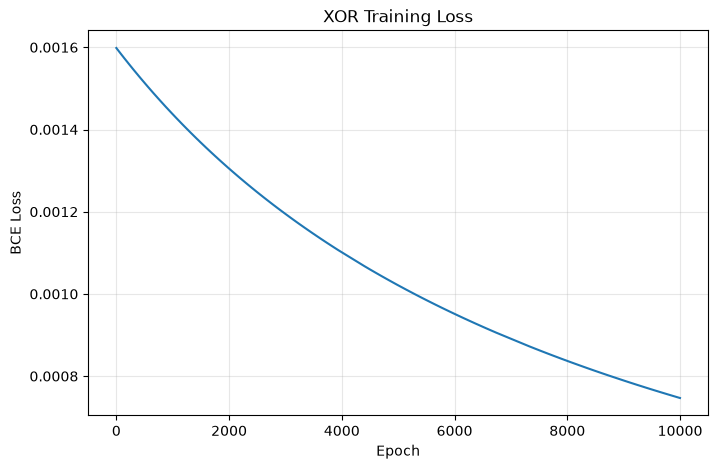

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("XOR Training Loss")
plt.grid(alpha=0.3)

plt.show()

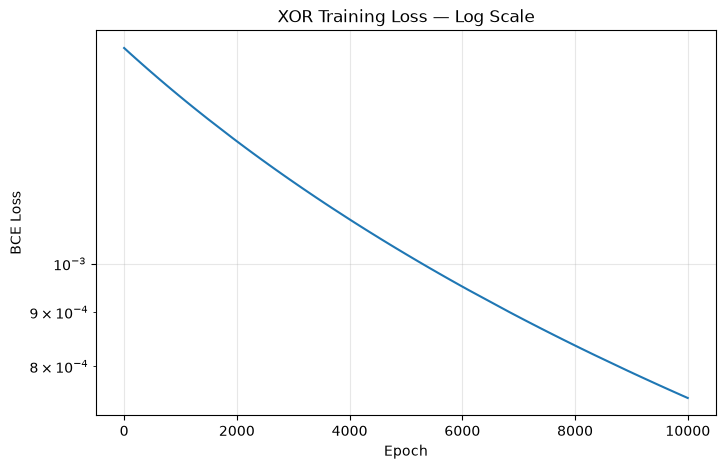

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("XOR Training Loss — Log Scale")
plt.yscale("log")
plt.grid(alpha=0.3)

plt.show()